this is for exploration  , run test and store metrics in results

In [ ]:
import sklearn



In [ ]:
import pandas as pd 
df = pd.read_csv('data/drug200.csv')
df.head(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [8]:
from sklearn.model_selection import train_test_split
X = df.drop('Drug' , axis = 1).values
Y = df['Drug'].values

In [12]:
print(X[:10])
print('-' * 30)
print(Y[:10])

[[23 'F' 'HIGH' 'HIGH' 25.355]
 [47 'M' 'LOW' 'HIGH' 13.093]
 [47 'M' 'LOW' 'HIGH' 10.114]
 [28 'F' 'NORMAL' 'HIGH' 7.798]
 [61 'F' 'LOW' 'HIGH' 18.043]
 [22 'F' 'NORMAL' 'HIGH' 8.607]
 [49 'F' 'NORMAL' 'HIGH' 16.275]
 [41 'M' 'LOW' 'HIGH' 11.037]
 [60 'M' 'NORMAL' 'HIGH' 15.171]
 [43 'M' 'LOW' 'NORMAL' 19.368]]
------------------------------
['DrugY' 'drugC' 'drugC' 'drugX' 'DrugY' 'drugX' 'DrugY' 'drugC' 'DrugY'
 'DrugY']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=125 )

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

cat_col = [1,2,3]
num_col = [0,4]

transform = ColumnTransformer(
    [
        ("encoder", OrdinalEncoder(), cat_col),
        ("num_imputer", SimpleImputer(strategy="median"), num_col),
        ("num_scaler", StandardScaler(), num_col),
    ]
)
pipe = Pipeline(
    steps=[
        ("preprocessing", transform),
        ("model", RandomForestClassifier(n_estimators=100, random_state=125)),
    ]
)
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('encoder', OrdinalEncoder(),
                                                  [1, 2, 3]),
                                                 ('num_imputer',
                                                  SimpleImputer(strategy='median'),
                                                  [0, 4]),
                                                 ('num_scaler',
                                                  StandardScaler(), [0, 4])])),
                ('model', RandomForestClassifier(random_state=125))])

In [32]:
from sklearn.metrics import f1_score
y_predict = pipe.predict(X_test)
f1 = f1_score(y_test, y_predict , average='macro')
print(round(f1 , 2))

with open('result/metrics.txt' , mode = 'w') as file:
    file.write(f'f1_score is {round(f1 , 2)}')

0.91


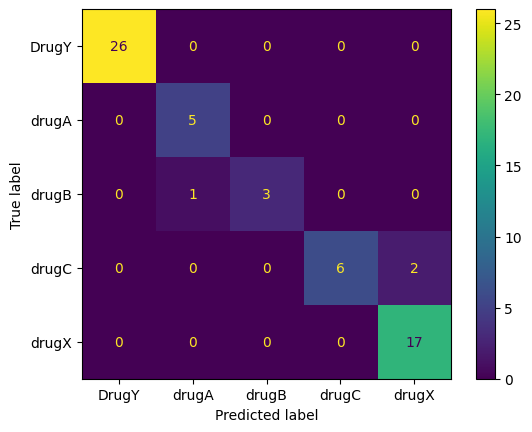

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
cm = confusion_matrix(y_test , y_predict , labels=pipe.classes_)
display = ConfusionMatrixDisplay(cm , display_labels = pipe.classes_)
display.plot()
plt.savefig('result/cm.png' , dpi = 120)

In [36]:
#save model
import pickle
with open ('model/drug_classification.pkl' , mode ='wb') as file : 
    pickle.dump(pipe , file)